In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("/Users/Nico/Desktop/DS5110/Project/Code/PREPROCESSED_NO_MISSING_UKNOWN.csv")
df_cleaned = df.drop(columns=['Unnamed: 0','state_fips_code','county_fips_code'])
df_extracleaned = df_cleaned.drop(columns=['res_state','res_county','process','case_month','icu_yn','current_status','death_yn','case_positive_specimen_interval','case_onset_interval'])

X = df_extracleaned.drop(columns='hosp_yn')
y = df_extracleaned['hosp_yn']
cols = df.columns

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_dummies = pd.get_dummies(X,drop_first=True)

print(pd.unique(y_encoded))
X_dummies

[0 1]


,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
0,0,True,False,False,False,False,False,False,False,True,True,True
1,0,False,False,True,True,False,False,False,False,True,True,True
2,0,True,False,False,True,False,False,False,False,True,False,True
3,0,True,False,False,False,False,True,False,False,False,True,True
4,0,True,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
53175,0,True,False,False,False,False,True,False,False,False,True,True
53176,1,False,False,True,True,False,False,False,False,True,True,True
53177,0,True,False,False,True,False,False,False,False,True,True,True
53178,0,True,False,False,False,False,True,False,False,False,True,True


In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train_val, X_test, y_train_val, y_test = train_test_split(X_dummies, y_encoded, test_size=0.2, random_state=42)
X_train_val

,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
46746,1,False,False,True,False,False,False,False,False,True,True,True
31252,1,True,False,False,False,False,True,False,False,False,True,True
6330,1,True,False,False,False,False,False,False,False,True,True,True
13670,0,False,True,False,False,False,True,False,False,False,True,True
8929,1,True,False,False,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0,True,False,False,False,False,False,False,False,True,True,True
44732,0,False,False,True,True,False,False,False,False,True,True,True
38158,1,False,True,False,False,False,False,False,False,True,False,True
860,0,True,False,False,False,False,False,False,False,True,True,True


In [35]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(
    random_state = 42,
    verbose = 1,
    scoring = 'accuracy',
    max_iter = 1000
)
model.fit(X_train_val, y_train_val)

/Users/Nico/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/Nico/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
[Parallel(n

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multi

/Users/Nico/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/Nico/.pyenv/versions/3.11.15/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/Nico

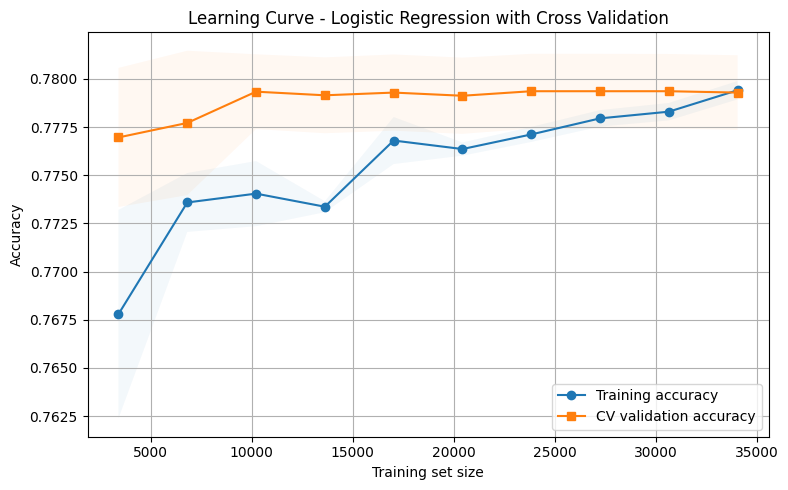

In [36]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_val, y_train_val,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, label="Training accuracy", marker="o")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.05)
ax.plot(train_sizes, val_mean, label="CV validation accuracy", marker="s")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.05)
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve - Logistic Regression with Cross Validation")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.show()


Accuracy: 0.774915381722452

Classification Report:
              precision    recall  f1-score   support

          No       0.78      0.98      0.87      8230
         Yes       0.52      0.08      0.14      2406

    accuracy                           0.77     10636
   macro avg       0.65      0.53      0.51     10636
weighted avg       0.72      0.77      0.71     10636


Confusion Matrix:


<Axes: title={'center': 'confusion_matrix'}>

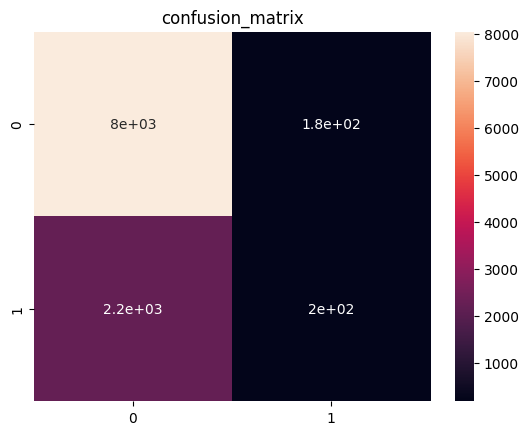

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
plt.figure()
# cmap = sns.color_palette(['#CAD733','#00BF00','#077187','#054ED9','#074F57','#EF3E36','#C056A5'], as_cmap=True)
cmap = sns.color_palette('rocket', as_cmap=True)
plt.title('confusion_matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap=cmap)

                                    Feature  Coefficient
                        age_group_65+ years     2.163808
race_Native Hawaiian/Other Pacific Islander     2.122955
                   age_group_50 to 64 years     1.377180
                                   pre_test     0.618199
               underlying_conditions_yn_Yes     0.499649
                   age_group_18 to 49 years     0.473248
              ethnicity_Non-Hispanic/Latino     0.386670
                                   sex_Male     0.271916
                                 race_White    -0.705165
                                 race_Asian    -0.740623
                                 race_Black    -0.757828
                        race_Multiple/Other    -0.783303


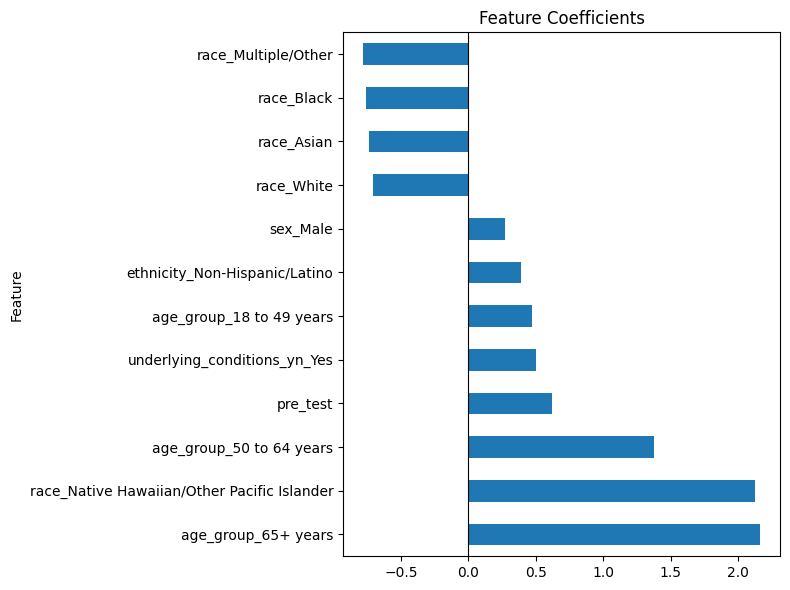

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_dummies.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

# Feature coefficients plot
coef_df.plot(kind='barh', x='Feature', y='Coefficient', figsize=(8, 6), legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients')
plt.tight_layout()
plt.show()

Note: Claude AI was used to support the postprocessing of the model after fitting the model to the data